In [1]:
import sys; sys.path.append('..')
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulator.loader import MarketDataLoader
from simulator.hmm import HybridJumpsHMM
from simulator.single_index import SingleIndexModel
from experts.markowitz import MarkowitzExpert
from torch.utils.data import random_split

# 1. Load config and extract variables cleanly
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

market_ticker = str(config["data"]["market_ticker"])
stock_tickers = list(config["data"]["stock_tickers"])

loader = MarketDataLoader(
    tickers=[market_ticker] + stock_tickers,
    start_date=config["data"]["start_date"], 
    end_date=config["data"]["end_date"]
)
data = loader.fetch_data()

# 2. Simulate standard HMM data
hmm = HybridJumpsHMM(n_states=config["hmm"]["n_states"])
hmm.fit(data[market_ticker])
best_eps, best_lambd = hmm.grid_search(data[market_ticker], max_lag=20, n_paths=10)

sim_model = SingleIndexModel(tickers=stock_tickers)
sim_model.fit(data[stock_tickers], data[market_ticker])
sim_states = hmm.simulate_states(config["hmm"]["simulation"]["n_steps"], best_eps, best_lambd)
sim_stocks = sim_model.simulate(hmm.decode_states(sim_states))

# 3. Get Ground Truth Labels from the Expert
expert = MarkowitzExpert(
    risk_aversion=config["expert"]["risk_aversion"],
    rolling_window=config["expert"]["rolling_window"],
    max_weight=config["expert"]["max_weight"],
    annual_risk_free_rate=config["expert"]["annual_risk_free_rate"]
)
expert_weights_df = expert.generate_labels(sim_stocks)

print(f"Data ready! Total trading days: {len(expert_weights_df)}")

Data ready! Total trading days: 2460


In [2]:
from agents.dataset import MLPPortfolioDataset
from agents.diffusion import MLPDenoiser, PortDiff
from agents.trainer import PortDiffTrainer
from torch.utils.data import Subset

window_size = config["expert"]["rolling_window"]
# 1. Create the dataset
dataset = MLPPortfolioDataset(
    returns_df=sim_stocks,
    weights_df=expert_weights_df,
    window_size=window_size
)

# 2. Split into 80% Training and 20% Validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Training on {train_size} days, Validating on {val_size} days.")

# 2. Chronological Split with Purge Gap (Zero Data Leakage)
total_days = len(dataset)
train_size = int(0.8 * total_days)
# Training set: Days 0 to train_size - 1
train_indices = list(range(0, train_size))
# Purge Gap: We drop 'window_size' days to prevent overlapping history
# (This ensures the validation set has absolutely no overlapping memory with the train set)
val_start = train_size + window_size
# Validation set: Days (train_size + gap) to the end
val_indices = list(range(val_start, total_days))
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
print(f"Total valid days: {total_days}")
print(f"Training on {len(train_dataset)} days (e.g., Years 1-8)")
print(f"Dropped {window_size} days to mathematically guarantee zero leakage")
print(f"Validating on {len(val_dataset)} strictly unseen future days")

# 3. Initialize the Neural Network and Diffusion Wrapper
state_dim = window_size * len(stock_tickers) # window_size * N stocks
action_dim = len(stock_tickers) + 1 # N stocks + Cash

denoiser = MLPDenoiser(
    state_dim=state_dim, 
    action_dim=action_dim, 
    hidden_dim=config["il"]["hidden_dim"],
    t_dim=config["il"]["t_dim"]
)

diffusion_model = PortDiff(
    denoiser=denoiser, 
    num_timesteps=config["il"]["num_timesteps"]
)

# 4. Train the Model
trainer = PortDiffTrainer(
    model=diffusion_model, 
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    learning_rate=config["il"]["learning_rate"], 
    batch_size=config["il"]["batch_size"]
)

trained_model = trainer.train(epochs=config["il"]["epochs"])

Training on 1968 days, Validating on 492 days.
Total valid days: 2460
Training on 1968 days (e.g., Years 1-8)
Dropped 60 days to mathematically guarantee zero leakage
Validating on 432 strictly unseen future days
Starting training on device: mps
Epoch 001 | Train Loss (MSE): 0.974603 | Val Loss (MSE): 0.917836
Epoch 010 | Train Loss (MSE): 0.154837 | Val Loss (MSE): 0.145676
Epoch 020 | Train Loss (MSE): 0.125564 | Val Loss (MSE): 0.145868
Epoch 030 | Train Loss (MSE): 0.117225 | Val Loss (MSE): 0.125479
Epoch 040 | Train Loss (MSE): 0.109716 | Val Loss (MSE): 0.114250
Epoch 050 | Train Loss (MSE): 0.096885 | Val Loss (MSE): 0.133042
Training complete!


Sampling portfolio weights from the Diffusion Model (this may take a minute)...
----------------------------------------
Equal-Weight Index Return: 3.57x | Sharpe: 0.68
Markowitz Expert Return:   8.45x | Sharpe: 0.93
PortDiff Agent Return:     3.49x | Sharpe: 0.68
----------------------------------------


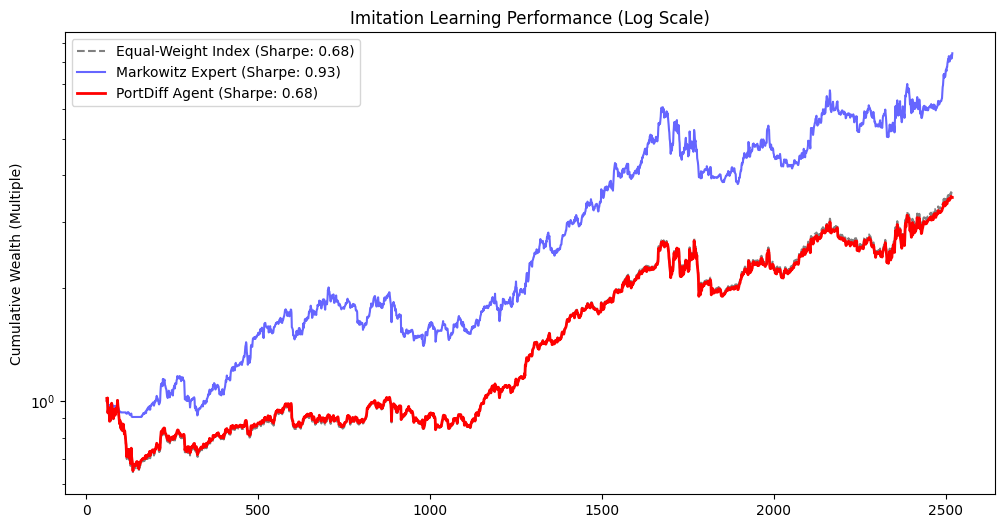

In [3]:
print("Sampling portfolio weights from the Diffusion Model (this may take a minute)...")

# 1. Grab the entire historical state matrix for all trading days
all_states = torch.as_tensor(dataset.X).to(trainer.device)

# 2. Ask the trained model to generate weights from pure noise (Inference)
with torch.no_grad():
    agent_weights_tensor = trained_model.sample(all_states)

# 3. Convert back to pandas DataFrame for easy math
agent_weights_df = pd.DataFrame(
    agent_weights_tensor.cpu().numpy(), 
    index=expert_weights_df.index, 
    columns=expert_weights_df.columns
)

# 4. Calculate Daily Returns for the Agent, the Expert, and the Naive Index
daily_rf = config["expert"]["annual_risk_free_rate"] / 252.0
sim_returns_with_cash = sim_stocks.copy()
sim_returns_with_cash["Cash"] = daily_rf
aligned_returns = sim_returns_with_cash.loc[expert_weights_df.index]

agent_daily_returns = (agent_weights_df * aligned_returns).sum(axis=1)
expert_daily_returns = (expert_weights_df * aligned_returns).sum(axis=1)

equal_weights = np.ones(len(stock_tickers)) / len(stock_tickers)
index_daily_returns = (sim_stocks.loc[expert_weights_df.index] * equal_weights).sum(axis=1)

# 5. Calculate Cumulative Returns
agent_cum_return = (1 + agent_daily_returns).cumprod()
expert_cum_return = (1 + expert_daily_returns).cumprod()
index_cum_return = (1 + index_daily_returns).cumprod()

# 6. Calculate Sharpe Ratios
agent_sharpe = np.sqrt(252) * (agent_daily_returns.mean() - daily_rf) / agent_daily_returns.std()
expert_sharpe = np.sqrt(252) * (expert_daily_returns.mean() - daily_rf) / expert_daily_returns.std()
index_sharpe = np.sqrt(252) * (index_daily_returns.mean() - daily_rf) / index_daily_returns.std()

# 7. Print Metrics and Plot
print("-" * 40)
print(f"Equal-Weight Index Return: {index_cum_return.iloc[-1]:.2f}x | Sharpe: {index_sharpe:.2f}")
print(f"Markowitz Expert Return:   {expert_cum_return.iloc[-1]:.2f}x | Sharpe: {expert_sharpe:.2f}")
print(f"PortDiff Agent Return:     {agent_cum_return.iloc[-1]:.2f}x | Sharpe: {agent_sharpe:.2f}")
print("-" * 40)

plt.figure(figsize=(12, 6))
plt.plot(index_cum_return, label=f"Equal-Weight Index (Sharpe: {index_sharpe:.2f})", color="gray", linestyle="--")
plt.plot(expert_cum_return, label=f"Markowitz Expert (Sharpe: {expert_sharpe:.2f})", color="blue", alpha=0.6)
plt.plot(agent_cum_return, label=f"PortDiff Agent (Sharpe: {agent_sharpe:.2f})", color="red", linewidth=2)
plt.yscale('log')
plt.title("Imitation Learning Performance (Log Scale)")
plt.ylabel("Cumulative Wealth (Multiple)")
plt.legend()
plt.show()